In [87]:
## automatically reload 
%reload_ext autoreload
%autoreload 2

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import NEOfaster as nf
import NEOMOD3 as nm3
import neoom as no
import S3Marray as sm
import S3M_fullversion as smfull
import neoonlyS3M as neo3m
import trojans as tjn
import importlib
from functools import reduce
importlib.reload(nm3)

<module 'NEOMOD3' from '/astro/users/ds2004/digest3/NEOMOD3.py'>

In [39]:
df, array4D, H_center, a_center, e_center, i_center = nm3.getNEOMOD3orbits()


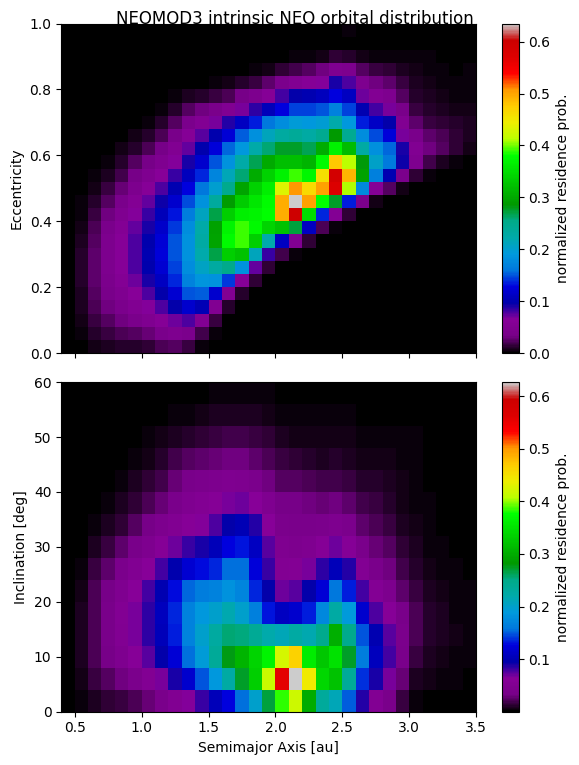

In [40]:
from scipy.ndimage import gaussian_filter

# ranges used in paper
h_sel = (H_center >= 15.0) & (H_center <= 28.0)
a_sel = (a_center >= 0.4)  & (a_center <= 3.5)
e_sel = (e_center >= 0.0)  & (e_center < 1.0)
i_sel = (i_center >= 0.0)  & (i_center <= 60.0)

# sets the 4d array to specific ranges
sub = array4D[h_sel, :, :, :]       # shape: (n_H_sel, n_a, n_e, n_i)

# a-e grid: sum over H and i
ae_sub = sub[:, a_sel, :, :]        # cut on a
ae_sub = ae_sub[:, :, e_sel, :]     # cut on e
ae_sub = ae_sub[:, :, :, i_sel]     # cut on i
ae_grid = ae_sub.sum(axis=(0, 3))   # sum over H (0) and i (3)
ae_grid = ae_grid / ae_grid.max()   # normalize max bin to 1

# a–i grid: sum over H and e
ai_sub = sub[:, a_sel, :, :]        
ai_sub = ai_sub[:, :, :, i_sel]     
ai_grid = ai_sub.sum(axis=(0, 2))   # sum over H (0) and e (2)
ai_grid = ai_grid / ai_grid.max()

# to make it more smooth

ae_grid_plot = gaussian_filter(ae_grid, sigma=0.7)
ai_grid_plot = gaussian_filter(ai_grid, sigma=0.7)


da = a_center[1] - a_center[0]
de = e_center[1] - e_center[0]
di = i_center[1] - i_center[0]

a_c = a_center[a_sel]
e_c = e_center[e_sel]
i_c = i_center[i_sel]

a_edges = np.concatenate(([a_c[0] - da/2], a_c + da/2))
e_edges = np.concatenate(([e_c[0] - de/2], e_c + de/2))
i_edges = np.concatenate(([i_c[0] - di/2], i_c + di/2))


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

# Panel (a): a–e
im1 = ax1.pcolormesh(a_edges, e_edges, ae_grid_plot.T,
                     shading='auto', cmap='nipy_spectral')
ax1.set_ylabel("Eccentricity")
ax1.set_ylim(0.0, 1.0)
cbar1 = fig.colorbar(im1, ax=ax1)
cbar1.set_label("normalized residence prob.")

# Panel (b): a–i
im2 = ax2.pcolormesh(a_edges, i_edges, ai_grid_plot.T,
                     shading='auto', cmap='nipy_spectral')
ax2.set_xlabel("Semimajor Axis [au]")
ax2.set_ylabel("Inclination [deg]")
ax2.set_ylim(0.0, 60.0)
cbar2 = fig.colorbar(im2, ax=ax2)
cbar2.set_label("normalized residence prob.")

fig.suptitle("NEOMOD3 intrinsic NEO orbital distribution", y=0.95)
fig.tight_layout()


In [41]:
s3m = sm.define_s3m()
s3m,array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m = sm.s3m_array(s3m)

['S1_00.s3m', 'S1_01.s3m', 'S1_02.s3m', 'S1_03.s3m', 'S1_04.s3m', 'S1_05.s3m', 'S1_06.s3m', 'S1_07.s3m', 'S1_08.s3m', 'S1_09.s3m', 'S1_10.s3m', 'S1_11.s3m', 'S1_12.s3m', 'S1_13.s3m']
The final df is done.


In [53]:
s3m.head()

,OID,FORMAT,q,e,i,node,argperi,t_p,H,t_0,INDEX,N_PAR,MOID,COMPCODE,a
0,S1000000a,COM,3.01822,0.05208,22.56035,211.00286,335.42134,51575.94061,14.20,54800.0,1,6,-1,Python,3.184045
1,S1000001a,COM,2.10974,0.07518,4.91571,209.40298,322.66447,54205.77161,20.57,54800.0,1,6,-1,Python,2.281244
2,S1000002a,COM,2.80523,0.07777,1.24945,112.52284,139.86858,54468.71747,14.65,54800.0,1,6,-1,Python,3.041790
3,S1000003a,COM,2.10917,0.13219,1.46615,266.54621,232.24412,54212.16304,19.58,54800.0,1,6,-1,Python,2.430451
4,S1000004a,COM,2.17676,0.19949,12.92422,162.14580,192.22312,51895.46586,10.56,54800.0,1,6,-1,Python,2.719216


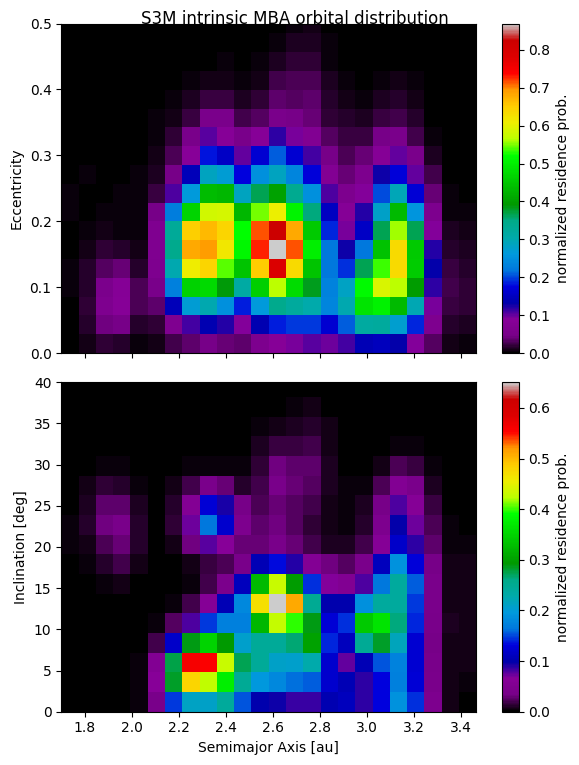

In [42]:
from scipy.ndimage import gaussian_filter

# ranges used in paper
h_sel1 = (H_center_s3m >= 15.0) & (H_center_s3m <= 28.0)
a_sel1 = (a_center_s3m >= 0.4)  & (a_center_s3m <= 3.5)
e_sel1 = (e_center_s3m >= 0.0)  & (e_center_s3m < 1.0)
i_sel1 = (i_center_s3m >= 0.0)  & (i_center_s3m <= 60.0)

# sets the 4d array to specific ranges
sub1 = array4D_s3m[h_sel1, :, :, :]       # shape: (n_H_sel, n_a, n_e, n_i)

# a-e grid: sum over H and i
ae_sub1 = sub1[:, a_sel1, :, :]        # cut on a
ae_sub1 = ae_sub1[:, :, e_sel1, :]     # cut on e
ae_sub1 = ae_sub1[:, :, :, i_sel1]     # cut on i
ae_grid1 = ae_sub1.sum(axis=(0, 3))   # sum over H (0) and i (3)
ae_grid1 = ae_grid1 / ae_grid1.max()   # normalize max bin to 1

# a–i grid: sum over H and e
ai_sub1 = sub1[:, a_sel1, :, :]        
ai_sub1 = ai_sub1[:, :, :, i_sel1]     
ai_grid1 = ai_sub1.sum(axis=(0, 2))   # sum over H (0) and e (2)
ai_grid1 = ai_grid1 / ai_grid1.max()

# to make it more smooth

ae_grid_plot1 = gaussian_filter(ae_grid1, sigma=0.7)
ai_grid_plot1 = gaussian_filter(ai_grid1, sigma=0.7)


da1 = a_center_s3m[1] - a_center_s3m[0]
de1 = e_center_s3m[1] - e_center_s3m[0]
di1 = i_center_s3m[1] - i_center_s3m[0]

a_c1 = a_center_s3m[a_sel1]
e_c1 = e_center_s3m[e_sel1]
i_c1 = i_center_s3m[i_sel1]

a_edges1 = np.concatenate(([a_c1[0] - da1/2], a_c1 + da1/2))
e_edges1 = np.concatenate(([e_c1[0] - de1/2], e_c1 + de1/2))
i_edges1 = np.concatenate(([i_c1[0] - di1/2], i_c1 + di1/2))


fig1, (ax1_s3m, ax2_s3m) = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

# Panel (a): a–e
im1_s3m = ax1_s3m.pcolormesh(a_edges1, e_edges1, ae_grid_plot1.T,
                     shading='auto', cmap='nipy_spectral')
ax1_s3m.set_ylabel("Eccentricity")
ax1_s3m.set_ylim(0.0, 0.5)
cbar1 = fig1.colorbar(im1_s3m, ax=ax1_s3m)
cbar1.set_label("normalized residence prob.")

# Panel (b): a–i
im2_s3m = ax2_s3m.pcolormesh(a_edges1, i_edges1, ai_grid_plot1.T,
                     shading='auto', cmap='nipy_spectral')
ax2_s3m.set_xlabel("Semimajor Axis [au]")
ax2_s3m.set_ylabel("Inclination [deg]")
ax2_s3m.set_ylim(0.0, 40.0)
cbar2 = fig1.colorbar(im2_s3m, ax=ax2_s3m)
cbar2.set_label("normalized residence prob.")

fig1.suptitle("S3M intrinsic MBA orbital distribution", y=0.95)
fig1.tight_layout()


In [43]:
s3m_full = smfull.define_s3m()

['S0.s3m', 'S1_00.s3m', 'S1_01.s3m', 'S1_02.s3m', 'S1_03.s3m', 'S1_04.s3m', 'S1_05.s3m', 'S1_06.s3m', 'S1_07.s3m', 'S1_08.s3m', 'S1_09.s3m', 'S1_10.s3m', 'S1_11.s3m', 'S1_12.s3m', 'S1_13.s3m', 'SH.s3m', 'SI.s3m', 'SJ.s3m', 'SL.s3m', 'SR.s3m', 'SS.s3m', 'ST.s3m', 'St5.s3m']
The final df is done.


In [57]:
s3m_full

,OID,FORMAT,q,e,i,node,argperi,t_p,H,t_0,INDEX,N_PAR,MOID,COMPCODE,a
0,S0000001a,COM,1.251459,0.382244,9.304721,252.063850,185.610748,54067.969964,10.315,54466.0,1,6,-1,MOPS,2.025814
1,S0000002a,COM,1.286219,0.662518,18.303865,132.486568,80.463153,54670.088589,10.818,54466.0,1,6,-1,MOPS,3.811219
2,S0000003a,COM,0.617193,0.645272,10.302493,67.484378,182.131418,54522.349738,11.175,54466.0,1,6,-1,MOPS,1.739907
3,S0000004a,COM,0.383306,0.856419,16.988463,117.793282,242.430598,54973.510299,11.452,54466.0,1,6,-1,MOPS,2.669612
4,S0000005a,COM,0.569264,0.772125,22.761089,314.323204,73.119299,54075.567352,11.678,54466.0,1,6,-1,MOPS,2.498139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14608600,St500KNfa,COM,5.056320,0.045220,15.566800,187.283000,151.605810,47151.013490,18.000,54800.0,1,6,-1,Python,5.295796
14608601,St500KNga,COM,4.782110,0.093630,13.513000,57.662000,275.327700,46937.239020,18.000,54800.0,1,6,-1,Python,5.276112
14608602,St500KNha,COM,4.773200,0.077770,10.543800,329.641000,149.433230,47733.392870,18.000,54800.0,1,6,-1,Python,5.175715
14608603,St500KNia,COM,4.997150,0.049460,34.880100,120.443000,284.497300,46679.404060,18.000,54800.0,1,6,-1,Python,5.257170


In [45]:
s3m,array4D_s3mfull, H_center_s3mfull, a_center_s3mfull, e_center_s3mfull, i_center_s3mfull = sm.s3m_array(s3m)

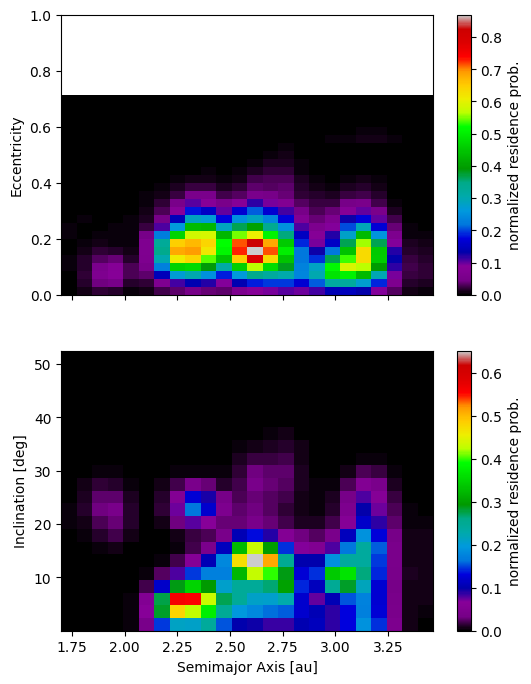

In [46]:
from scipy.ndimage import gaussian_filter

# ranges used in paper
h_sel2 = (H_center_s3mfull >= 15.0) & (H_center_s3mfull <= 28.0)
a_sel2 = (a_center_s3mfull >= 0.4)  & (a_center_s3mfull <= 3.5)
e_sel2 = (e_center_s3mfull >= 0.0)  & (e_center_s3mfull < 1.0)
i_sel2 = (i_center_s3mfull >= 0.0)  & (i_center_s3mfull <= 60.0)

# sets the 4d array to specific ranges
sub2 = array4D_s3mfull[h_sel2, :, :, :]       # shape: (n_H_sel, n_a, n_e, n_i)

# a-e grid: sum over H and i
ae_sub2 = sub2[:, a_sel2, :, :]        # cut on a
ae_sub2 = ae_sub2[:, :, e_sel2, :]     # cut on e
ae_sub2 = ae_sub2[:, :, :, i_sel2]     # cut on i
ae_grid2 = ae_sub2.sum(axis=(0, 3))   # sum over H (0) and i (3)
ae_grid2 = ae_grid2 / ae_grid2.max()   # normalize max bin to 1

# a–i grid: sum over H and e
ai_sub2 = sub2[:, a_sel2, :, :]        
ai_sub2 = ai_sub2[:, :, :, i_sel2]     
ai_grid2 = ai_sub2.sum(axis=(0, 2))   # sum over H (0) and e (2)
ai_grid2 = ai_grid2 / ai_grid2.max()

# to make it more smooth

ae_grid_plot2 = gaussian_filter(ae_grid2, sigma=0.7)
ai_grid_plot2 = gaussian_filter(ai_grid2, sigma=0.7)


da2 = a_center_s3m[1] - a_center_s3m[0]
de2 = e_center_s3m[1] - e_center_s3m[0]
di2 = i_center_s3m[1] - i_center_s3m[0]

a_c2 = a_center_s3mfull[a_sel2]
e_c2 = e_center_s3mfull[e_sel2]
i_c2 = i_center_s3mfull[i_sel2]

a_edges2 = np.concatenate(([a_c2[0] - da2/2], a_c2 + da2/2))
e_edges2 = np.concatenate(([e_c2[0] - de2/2], e_c2 + de2/2))
i_edges2 = np.concatenate(([i_c2[0] - di2/2], i_c2 + di2/2))


fig2, (ax1_s3mfull, ax2_s3mfull) = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

# Panel (a): a–e
im1_s3mfull = ax1_s3mfull.pcolormesh(a_edges2, e_edges2, ae_grid_plot2.T,
                     shading='auto', cmap='nipy_spectral')
ax1_s3mfull.set_ylabel("Eccentricity")
ax1_s3mfull.set_ylim(0.0, 1.0)
cbar1 = fig2.colorbar(im1_s3mfull, ax=ax1_s3mfull)
cbar1.set_label("normalized residence prob.")

# Panel (b): a–i
im2_s3mfull = ax2_s3mfull.pcolormesh(a_edges2, i_edges2, ai_grid_plot2.T,
                     shading='auto', cmap='nipy_spectral')
ax2_s3mfull.set_xlabel("Semimajor Axis [au]")
ax2_s3mfull.set_ylabel("Inclination [deg]")
ax2_s3m.set_ylim(0.0, 60.0)
cbar2 = fig2.colorbar(im2_s3mfull, ax=ax2_s3mfull)
cbar2.set_label("normalized residence prob.")

fig1.suptitle("S3M intrinsic MBA orbital distribution", y=0.95)
fig1.tight_layout()


In [ ]:
# now with only neo from s3m

In [65]:
neo_s3m = neo3m.define_s3m()

['S0.s3m']
The final df is done.


In [66]:
neo_s3m

,OID,FORMAT,q,e,i,node,argperi,t_p,H,t_0,INDEX,N_PAR,MOID,COMPCODE,a
0,S0000001a,COM,1.251459,0.382244,9.304721,252.063850,185.610748,54067.969964,10.315,54466.0,1,6,-1,MOPS,2.025814
1,S0000002a,COM,1.286219,0.662518,18.303865,132.486568,80.463153,54670.088589,10.818,54466.0,1,6,-1,MOPS,3.811219
2,S0000003a,COM,0.617193,0.645272,10.302493,67.484378,182.131418,54522.349738,11.175,54466.0,1,6,-1,MOPS,1.739907
3,S0000004a,COM,0.383306,0.856419,16.988463,117.793282,242.430598,54973.510299,11.452,54466.0,1,6,-1,MOPS,2.669612
4,S0000005a,COM,0.569264,0.772125,22.761089,314.323204,73.119299,54075.567352,11.678,54466.0,1,6,-1,MOPS,2.498139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268506,S00019Npa,COM,1.120493,0.719870,7.215564,352.065443,22.728064,54356.369662,25.000,54466.0,1,6,-1,MOPS,3.999912
268507,S00019Nqa,COM,0.138585,0.904027,42.936671,97.053777,141.837873,54708.693935,25.000,54466.0,1,6,-1,MOPS,1.443995
268508,S00019Nra,COM,0.183840,0.741100,39.592137,226.887464,45.405407,54453.982901,25.000,54466.0,1,6,-1,MOPS,0.710082
268509,S00019Nsa,COM,1.005092,0.580448,11.451065,194.025698,170.089706,54067.389305,25.000,54466.0,1,6,-1,MOPS,2.395632


In [110]:
neo_s3m,array4D_neo, H_center_neo, a_center_neo, e_center_neo, i_center_neo = neo3m.s3m_array(neo_s3m)

In [111]:
neo_s3m

,OID,FORMAT,q,e,i,node,argperi,t_p,H,t_0,INDEX,N_PAR,MOID,COMPCODE,a
0,S0000001a,COM,1.251459,0.382244,9.304721,252.063850,185.610748,54067.969964,10.315,54466.0,1,6,-1,MOPS,2.025814
1,S0000002a,COM,1.286219,0.662518,18.303865,132.486568,80.463153,54670.088589,10.818,54466.0,1,6,-1,MOPS,3.811219
2,S0000003a,COM,0.617193,0.645272,10.302493,67.484378,182.131418,54522.349738,11.175,54466.0,1,6,-1,MOPS,1.739907
3,S0000004a,COM,0.383306,0.856419,16.988463,117.793282,242.430598,54973.510299,11.452,54466.0,1,6,-1,MOPS,2.669612
4,S0000005a,COM,0.569264,0.772125,22.761089,314.323204,73.119299,54075.567352,11.678,54466.0,1,6,-1,MOPS,2.498139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268506,S00019Npa,COM,1.120493,0.719870,7.215564,352.065443,22.728064,54356.369662,25.000,54466.0,1,6,-1,MOPS,3.999912
268507,S00019Nqa,COM,0.138585,0.904027,42.936671,97.053777,141.837873,54708.693935,25.000,54466.0,1,6,-1,MOPS,1.443995
268508,S00019Nra,COM,0.183840,0.741100,39.592137,226.887464,45.405407,54453.982901,25.000,54466.0,1,6,-1,MOPS,0.710082
268509,S00019Nsa,COM,1.005092,0.580448,11.451065,194.025698,170.089706,54067.389305,25.000,54466.0,1,6,-1,MOPS,2.395632


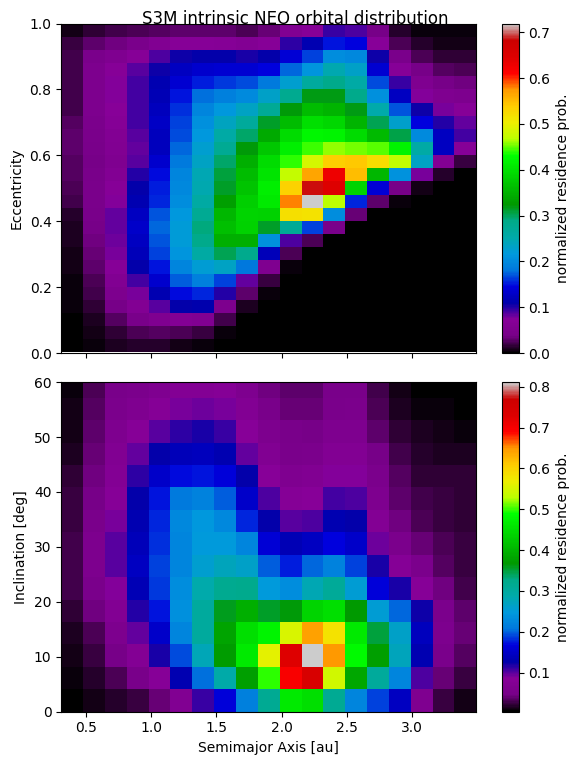

In [113]:
from scipy.ndimage import gaussian_filter

# ranges used in paper
h_sel3 = (H_center_neo >= 15.0) & (H_center_neo <= 28.0)
a_sel3 = (a_center_neo >= 0.0)  & (a_center_neo <= 3.5)
e_sel3 = (e_center_neo >= 0.0)  & (e_center_neo < 1.0)
i_sel3 = (i_center_neo >= 0.0)  & (i_center_neo <= 60.0)

# sets the 4d array to specific ranges
sub3 = array4D_neo[h_sel3, :, :, :]       # shape: (n_H_sel, n_a, n_e, n_i)

# a-e grid: sum over H and i
ae_sub3 = sub3[:, a_sel3, :, :]        # cut on a
ae_sub3 = ae_sub3[:, :, e_sel3, :]     # cut on e
ae_sub3 = ae_sub3[:, :, :, i_sel3]     # cut on i
ae_grid3 = ae_sub3.sum(axis=(0, 3))   # sum over H (0) and i (3)
ae_grid3 = ae_grid3 / ae_grid3.max()   # normalize max bin to 1

# a–i grid: sum over H and e
ai_sub3 = sub3[:, a_sel3, :, :]        
ai_sub3 = ai_sub3[:, :, :, i_sel3]     
ai_grid3 = ai_sub3.sum(axis=(0, 2))   # sum over H (0) and e (2)
ai_grid3 = ai_grid3 / ai_grid3.max()

# to make it more smooth

ae_grid_plot3 = gaussian_filter(ae_grid3, sigma=0.7)
ai_grid_plot3 = gaussian_filter(ai_grid3, sigma=0.7)


da3 = a_center_neo[1] - a_center_neo[0]
de3 = e_center_neo[1] - e_center_neo[0]
di3 = i_center_neo[1] - i_center_neo[0]

a_c3 = a_center_neo[a_sel3]
e_c3 = e_center_neo[e_sel3]
i_c3 = i_center_neo[i_sel3]

a_edges3 = np.concatenate(([a_c3[0] - da3/2], a_c3 + da3/2))
e_edges3 = np.concatenate(([e_c3[0] - de3/2], e_c3 + de3/2))
i_edges3 = np.concatenate(([i_c3[0] - di3/2], i_c3 + di3/2))


fig3, (ax1_neo3m, ax2_neo3m) = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

# Panel (a): a–e
im1_neo3m = ax1_neo3m.pcolormesh(a_edges3, e_edges3, ae_grid_plot3.T,
                     shading='auto', cmap='nipy_spectral')
ax1_neo3m.set_ylabel("Eccentricity")
ax1_neo3m.set_ylim(0.0, 1.0)

cbar1_neo = fig3.colorbar(im1_neo3m, ax=ax1_neo3m)
cbar1_neo.set_label("normalized residence prob.")

# Panel (b): a–i
im2_neo3m = ax2_neo3m.pcolormesh(a_edges3, i_edges3, ai_grid_plot3.T,
                     shading='auto', cmap='nipy_spectral')
ax2_neo3m.set_xlabel("Semimajor Axis [au]")
ax2_neo3m.set_ylabel("Inclination [deg]")
ax2_neo3m.set_ylim(0.0, 60.0)
cbar2_neo = fig3.colorbar(im2_neo3m, ax=ax2_neo3m)
cbar2_neo.set_label("normalized residence prob.")

fig3.suptitle("S3M intrinsic NEO orbital distribution", y=0.95)
fig3.tight_layout()


In [108]:
print("H bins selected:", h_sel3.sum())
print("a bins selected:", a_sel3.sum())
print("e bins selected:", e_sel3.sum())
print("i bins selected:", i_sel3.sum())
print("H range:", H_center_neo.min(), "to", H_center_neo.max())
print("a range:", a_center_neo.min(), "to", a_center_neo.max())
print("e range:", e_center_neo.min(), "to", e_center_neo.max())
print("i range:", i_center_neo.min(), "to", i_center_neo.max())


H bins selected: 13
a bins selected: 0
e bins selected: 25
i bins selected: 22
H range: 5.748942307692308 to 17.881057692307692
a range: 5.035361824694418 to 5.391689273457848
e range: 0.0054772000000000015 to 0.26118280000000005
i range: 1.3688545454545453 to 57.99554545454545


In [89]:
trojans_s3m = tjn.define_s3m()

['St5.s3m']
The final df is done.


In [90]:
trojans_s3m

,OID,FORMAT,q,e,i,node,argperi,t_p,H,t_0,INDEX,N_PAR,MOID,COMPCODE,a
0,St500000a,COM,4.91636,0.05966,7.6084,313.711,150.14863,47268.27529,5.63,54800.0,1,6,-1,Python,5.228279
1,St500001a,COM,4.96652,0.06370,10.4414,100.539,243.70619,54669.39282,6.25,54800.0,1,6,-1,Python,5.304411
2,St500002a,COM,5.01980,0.03319,6.7215,166.404,31.12803,52845.06297,6.36,54800.0,1,6,-1,Python,5.192127
3,St500003a,COM,4.75104,0.09715,18.3859,41.238,206.31396,54666.09533,6.61,54800.0,1,6,-1,Python,5.262269
4,St500004a,COM,4.91459,0.05269,26.1707,188.834,92.77871,46950.71510,6.92,54800.0,1,6,-1,Python,5.187943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179877,St500KNfa,COM,5.05632,0.04522,15.5668,187.283,151.60581,47151.01349,18.00,54800.0,1,6,-1,Python,5.295796
179878,St500KNga,COM,4.78211,0.09363,13.5130,57.662,275.32770,46937.23902,18.00,54800.0,1,6,-1,Python,5.276112
179879,St500KNha,COM,4.77320,0.07777,10.5438,329.641,149.43323,47733.39287,18.00,54800.0,1,6,-1,Python,5.175715
179880,St500KNia,COM,4.99715,0.04946,34.8801,120.443,284.49730,46679.40406,18.00,54800.0,1,6,-1,Python,5.257170


In [94]:
tjn_s3m,array4D_tjn, H_center_tjn, a_center_tjn, e_center_tjn, i_center_tjn = tjn.s3m_array(trojans_s3m)

In [95]:
tjn_s3m

,OID,FORMAT,q,e,i,node,argperi,t_p,H,t_0,INDEX,N_PAR,MOID,COMPCODE,a
0,St500000a,COM,4.91636,0.05966,7.6084,313.711,150.14863,47268.27529,5.63,54800.0,1,6,-1,Python,5.228279
1,St500001a,COM,4.96652,0.06370,10.4414,100.539,243.70619,54669.39282,6.25,54800.0,1,6,-1,Python,5.304411
2,St500002a,COM,5.01980,0.03319,6.7215,166.404,31.12803,52845.06297,6.36,54800.0,1,6,-1,Python,5.192127
3,St500003a,COM,4.75104,0.09715,18.3859,41.238,206.31396,54666.09533,6.61,54800.0,1,6,-1,Python,5.262269
4,St500004a,COM,4.91459,0.05269,26.1707,188.834,92.77871,46950.71510,6.92,54800.0,1,6,-1,Python,5.187943
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179877,St500KNfa,COM,5.05632,0.04522,15.5668,187.283,151.60581,47151.01349,18.00,54800.0,1,6,-1,Python,5.295796
179878,St500KNga,COM,4.78211,0.09363,13.5130,57.662,275.32770,46937.23902,18.00,54800.0,1,6,-1,Python,5.276112
179879,St500KNha,COM,4.77320,0.07777,10.5438,329.641,149.43323,47733.39287,18.00,54800.0,1,6,-1,Python,5.175715
179880,St500KNia,COM,4.99715,0.04946,34.8801,120.443,284.49730,46679.40406,18.00,54800.0,1,6,-1,Python,5.257170


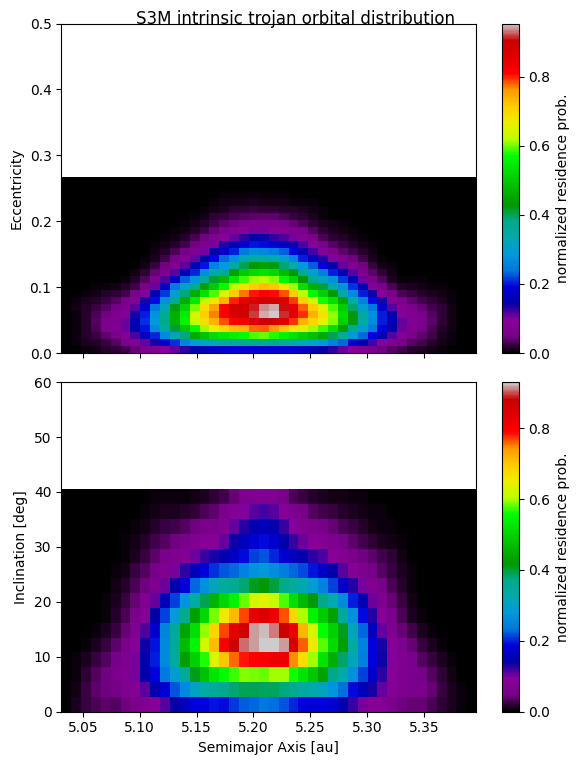

In [114]:
from scipy.ndimage import gaussian_filter

# ranges used in paper
h_sel4 = (H_center_tjn >= 15.0) & (H_center_tjn <= 28.0)
a_sel4 = (a_center_tjn >= 3.5)  & (a_center_tjn <= 6.0)
e_sel4 = (e_center_tjn >= 0.0)  & (e_center_tjn < 0.5)
i_sel4 = (i_center_tjn >= 0.0)  & (i_center_tjn <= 40.0)

# sets the 4d array to specific ranges
sub4 = array4D_tjn[h_sel4, :, :, :]       # shape: (n_H_sel, n_a, n_e, n_i)

# a-e grid: sum over H and i
ae_sub4 = sub4[:, a_sel4, :, :]        # cut on a
ae_sub4 = ae_sub4[:, :, e_sel4, :]     # cut on e
ae_sub4 = ae_sub4[:, :, :, i_sel4]     # cut on i
ae_grid4 = ae_sub4.sum(axis=(0, 3))   # sum over H (0) and i (3)
ae_grid4 = ae_grid4 / ae_grid4.max()   # normalize max bin to 1

# a–i grid: sum over H and e
ai_sub4 = sub4[:, a_sel4, :, :]        
ai_sub4 = ai_sub4[:, :, :, i_sel4]     
ai_grid4 = ai_sub4.sum(axis=(0, 2))   # sum over H (0) and e (2)
ai_grid4 = ai_grid4 / ai_grid4.max()

# to make it more smooth

ae_grid_plot4 = gaussian_filter(ae_grid4, sigma=0.7)
ai_grid_plot4 = gaussian_filter(ai_grid4, sigma=0.7)


da4 = a_center_tjn[1] - a_center_tjn[0]
de4 = e_center_tjn[1] - e_center_tjn[0]
di4 = i_center_tjn[1] - i_center_tjn[0]

a_c4 = a_center_tjn[a_sel4]
e_c4 = e_center_tjn[e_sel4]
i_c4 = i_center_tjn[i_sel4]

a_edges4 = np.concatenate(([a_c4[0] - da4/2], a_c4 + da4/2))
e_edges4 = np.concatenate(([e_c4[0] - de4/2], e_c4 + de4/2))
i_edges4 = np.concatenate(([i_c4[0] - di4/2], i_c4 + di4/2))


fig4, (ax1_tjn, ax2_tjn) = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

# Panel (a): a–e
im1_tjn = ax1_tjn.pcolormesh(a_edges4, e_edges4, ae_grid_plot4.T,
                     shading='auto', cmap='nipy_spectral')
ax1_tjn.set_ylabel("Eccentricity")
ax1_tjn.set_ylim(0.0, 0.5)

cbar1_tjn = fig4.colorbar(im1_tjn, ax=ax1_tjn)
cbar1_tjn.set_label("normalized residence prob.")

# Panel (b): a–i
im2_tjn = ax2_tjn.pcolormesh(a_edges4, i_edges4, ai_grid_plot4.T,
                     shading='auto', cmap='nipy_spectral')
ax2_tjn.set_xlabel("Semimajor Axis [au]")
ax2_tjn.set_ylabel("Inclination [deg]")
ax2_tjn.set_ylim(0.0, 60.0)
cbar2_tjn = fig4.colorbar(im2_tjn, ax=ax2_tjn)
cbar2_tjn.set_label("normalized residence prob.")

fig4.suptitle("S3M intrinsic trojan orbital distribution", y=0.95)
fig4.tight_layout()
